In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# Uploud Data

- quick explore the dataset.
- clean the dataset.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/samsung_global_sales_dataset.csv')

df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [ ]:
df.shape

(15500, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [ ]:
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,11249.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.743515
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.721258
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.100000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.400000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


In [ ]:
df.describe(include='object')

,sale_id,sale_date,quarter,month,country,region,city,product_name,category,storage,color,is_5g,currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,return_status
count,15500,15500,15500,15500,15500,15500,15500,15500,15500,7651,15500,15500,15500,15500,15500,15500,15500,6127,15500
unique,15500,1461,4,12,52,8,555,73,11,5,34,2,44,7,8,5,5,5,3
top,SAMS-00015500,2022-01-12,Q2,June,Norway,Europe,Singapore,Samsung Galaxy Tab S9 FE,Galaxy S,256 GB,Black,No,EUR,E-commerce Platform,Cash,Government,25–34,Android (Samsung),Kept
freq,1,23,3986,1376,328,5327,270,250,2316,2162,1962,10429,2693,2272,1999,3140,3227,1344,13315


## Meaning of dataset columns:


- sale_id	strin: transaction ID —SAMS-XXXXXXXX
- sale_date: Transaction date YYYY-MM-DD
- year: 2021 / 2022 / 2023 / 2024
- quarter: Q1 / Q2 / Q3 / Q4
- month: Full month name
- country: Country of sale
- region: Continent / geo-region
- city: City of sale
- product_name: Full product name
- category: Galaxy S / Galaxy Z / Galaxy A / Galaxy M / Galaxy Tab / Galaxy Watch / Galaxy Buds / Monitor / Smart TV / Appliances / Accessories
- storage: Storage variant (N/A for non-storage products)
- color: Colour option
- is_5g: Whether the device is 5G-capable: Yes / No
- unit_price_usd: Per-unit list price in USD (±9 % market jitter)
- discount_pct: Discount applied: 0, 2, 3, 5, 7, 10, 12, 15, or 20 %
- units_sold: Quantity in this transaction (1–10, skewed toward 1)
- discounted_price_usd: Effective per-unit price after discount
- revenue_usd: Total transaction revenue in USD
- currency: Local currency code
- fx_rate_to_usd: Exchange rate used for conversion
- revenue_local_currency: Revenue in local currency
- sales_channel: Samsung Store / Online / Reseller / Carrier / Retailer / B2B / E-commerce
- payment_method: Credit Card / Debit Card / Samsung Pay / EMI / Net Banking / Cash / Gift Card / BNPL
- customer_segment: Individual / Business / Education / Government / Enterprise
- customer_age_group: 18–24 / 25–34 / 35–44 / 45–54 / 55+
- previous_device_os	string	Buyer's previous OS (phones only; others →N/A)
- customer_rating: Post-purchase rating 2.5–5.0; ~28 % are NaN
- return_status: Kept / Returned / Exchanged

In [ ]:
df['total_transaction_price'] = df['discounted_price_usd'] * df['units_sold']

df.head(5)

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status,total_transaction_price
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept,1246.77
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept,1457.72
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept,2165.82
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept,728.07
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept,3125.96


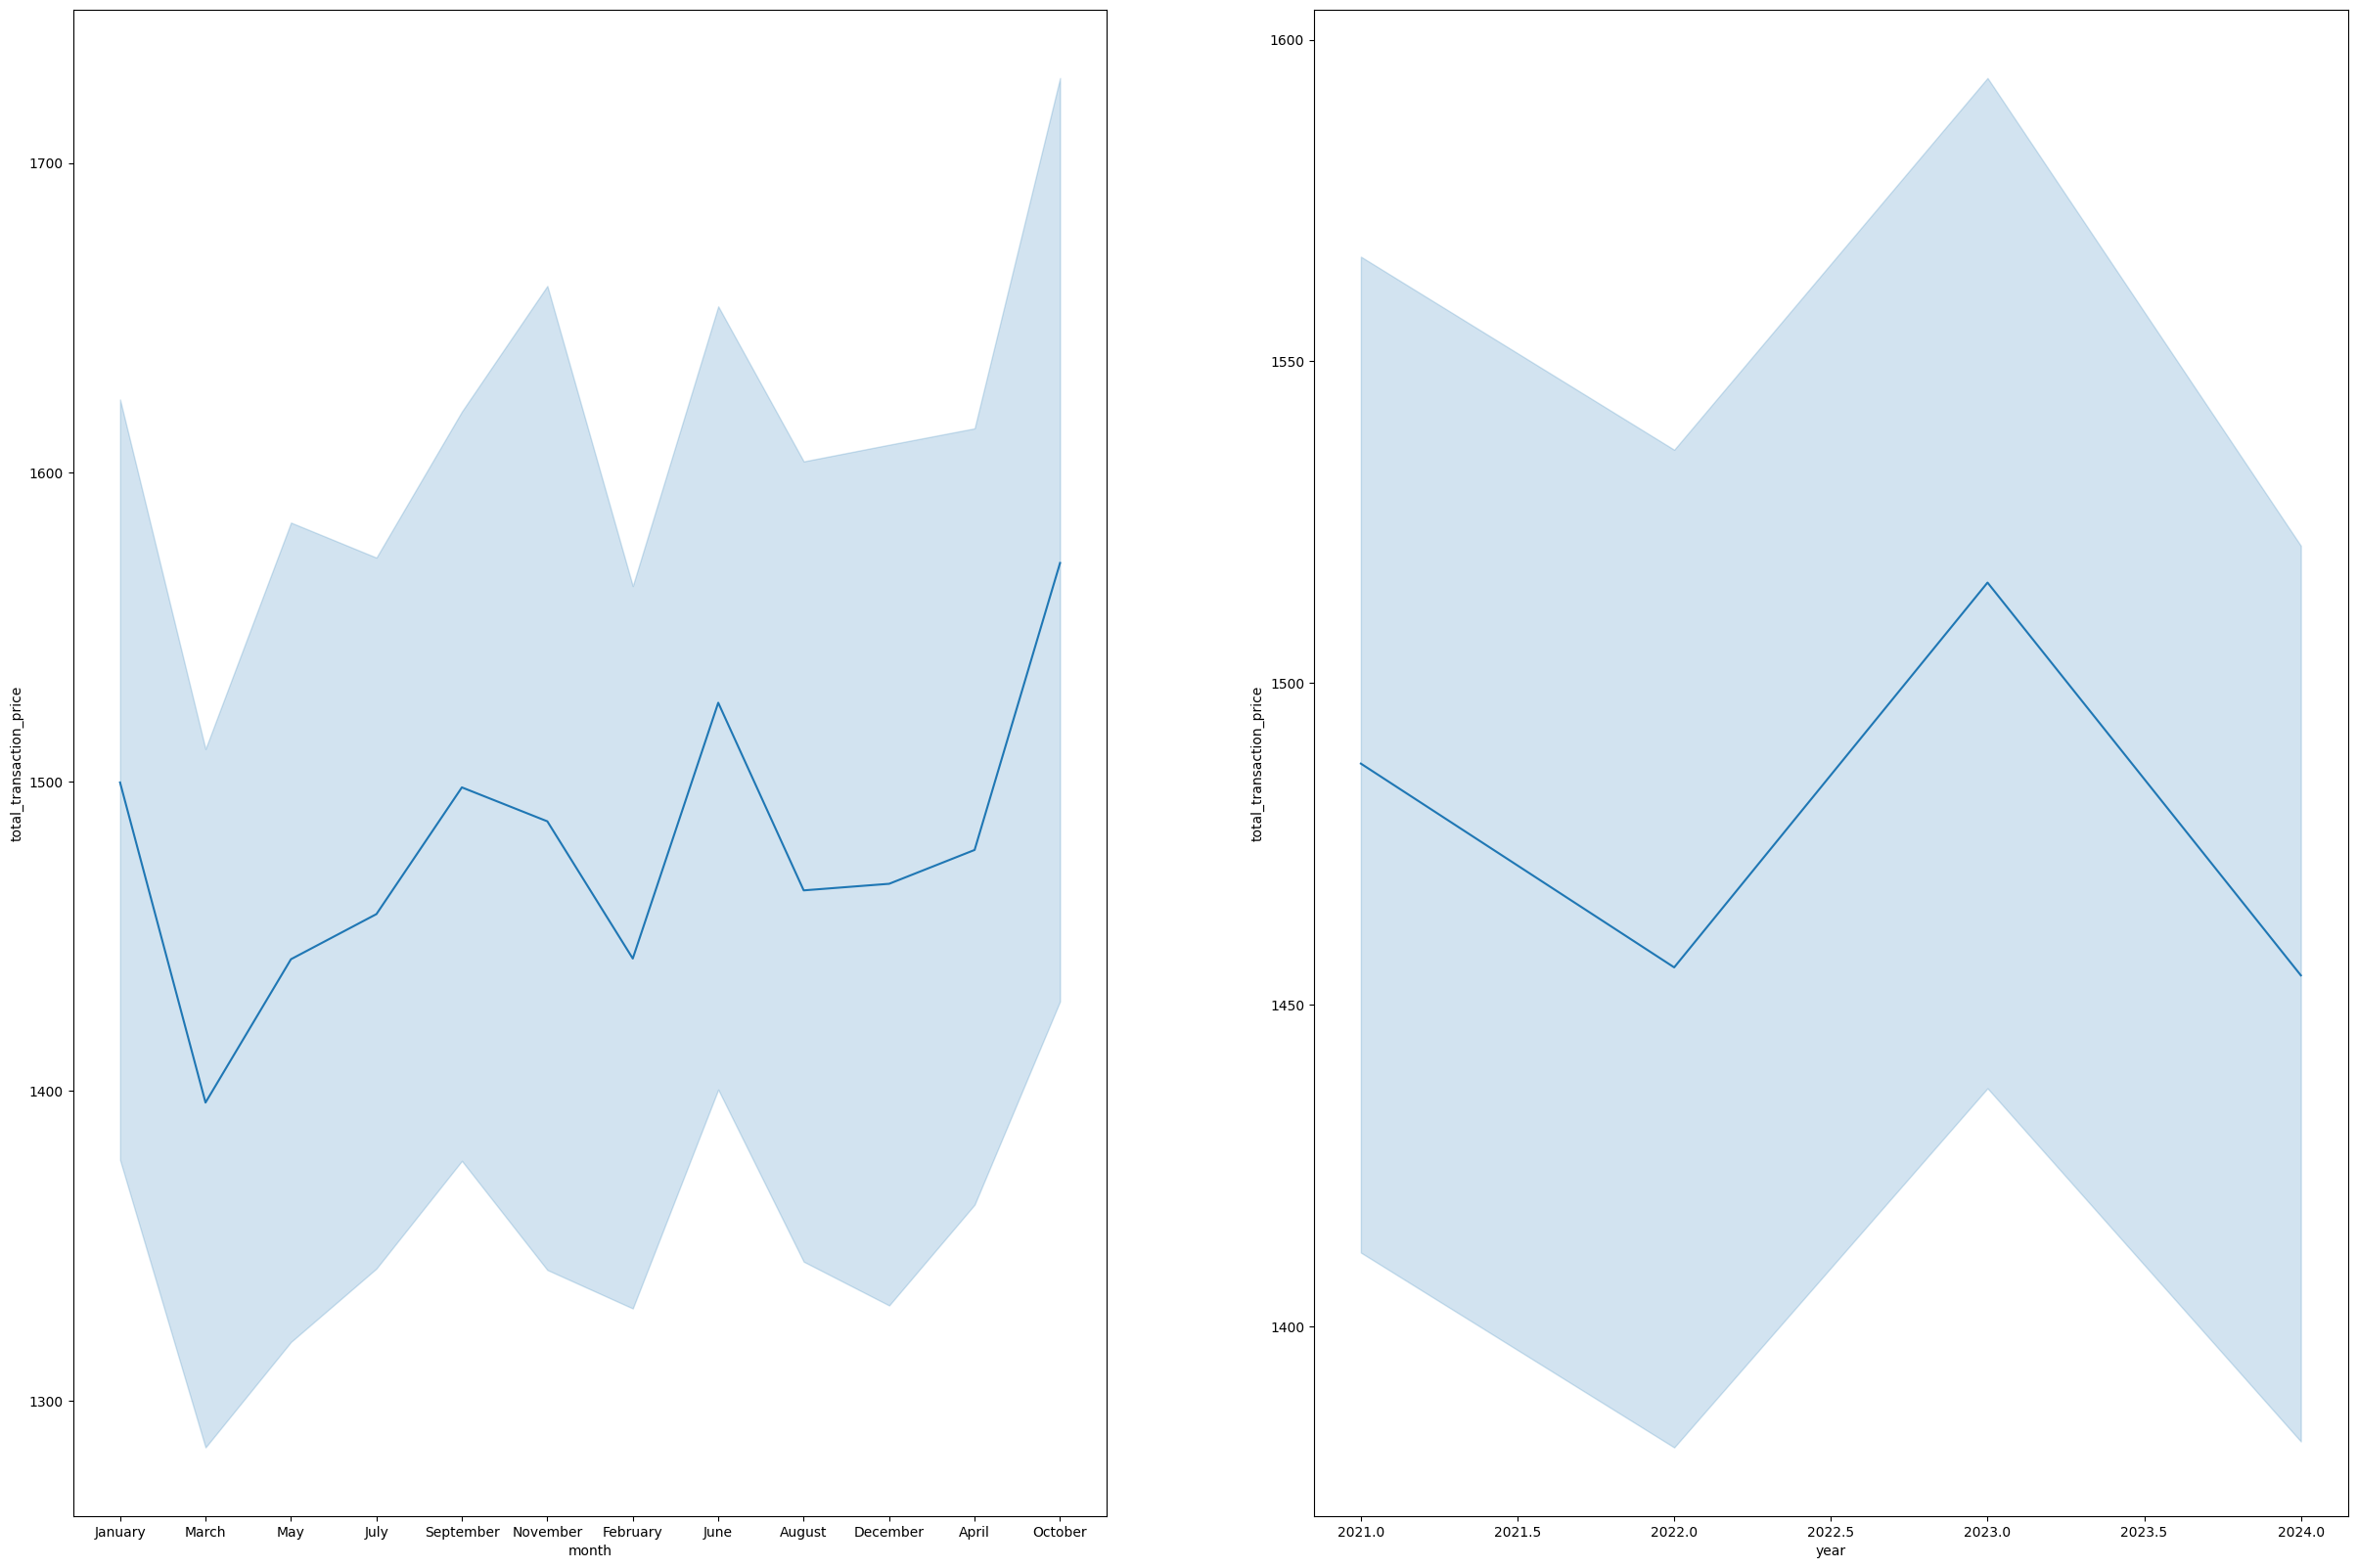

In [ ]:
# Explore data:

fig, axes = plt.subplots( 1, 2, figsize=(30, 20))

sn.lineplot(data=df, x='month', y='total_transaction_price', ax=axes[0])
sn.lineplot(data=df, x='year', y='total_transaction_price', ax=axes[1])

plt.show()

In [ ]:
df['country'].unique()

array(['Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium',
       'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Czech Republic',
       'Denmark', 'Egypt', 'Ethiopia', 'France', 'Germany', 'Greece',
       'India', 'Indonesia', 'Italy', 'Japan', 'Kenya', 'Malaysia',
       'Mexico', 'Myanmar', 'Netherlands', 'New Zealand', 'Nigeria',
       'Norway', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Portugal',
       'Romania', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa',
       'South Korea', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland',
       'Taiwan', 'Thailand', 'Turkey', 'UAE', 'Ukraine', 'United Kingdom',
       'United States', 'Vietnam'], dtype=object)

In [ ]:
df.groupby(by='country')['total_transaction_price'].sum().sort_values()

,total_transaction_price
country,
Saudi Arabia,353226.52
Peru,354245.98
Belgium,361647.50
Philippines,371469.98
Netherlands,373662.73
New Zealand,377018.99
Switzerland,378224.96
China,380012.21
Russia,386479.27


In [ ]:
country_ser = df.groupby(by='country')['total_transaction_price'].sum().nlargest(10)

In [ ]:
val = df.loc[df['country'] == 'Saudi Arabia']['total_transaction_price'].sum()

In [ ]:
country_ser.loc['Saudi Arabia'] = val

In [ ]:
country_ser

,total_transaction_price
country,
Greece,551966.07
UAE,533780.97
Austria,529642.09
Norway,522623.37
France,522563.49
Canada,515495.34
South Korea,509915.68
Taiwan,500483.33
Sri Lanka,492857.08


In [ ]:
product_ser = df.groupby('product_name')['total_transaction_price'].sum().nlargest(10)

In [ ]:
product_ser

,total_transaction_price
product_name,
Samsung Neo QLED 8K QN900C,2231009.59
Samsung OLED S95C 65-inch,1222086.81
Samsung French Door Refrigerator,914370.15
Samsung Neo QLED 4K QN85C,859697.30
Samsung Galaxy Z Fold 5,858492.72
Samsung Galaxy Z Fold 4,763137.30
Samsung ViewFinity S9,746484.03
Samsung Odyssey Neo G9,651827.53
Samsung The Frame 55-inch,618187.82


In [ ]:
filtered_country_df = df.loc[df['country'].isin(country_ser.index)]

In [ ]:
filtered_country_df.shape

(3420, 29)

In [ ]:
filtered_product_df = df.loc[df['product_name'].isin(product_ser.index)]

In [ ]:
filtered_product_df.shape

(2161, 29)

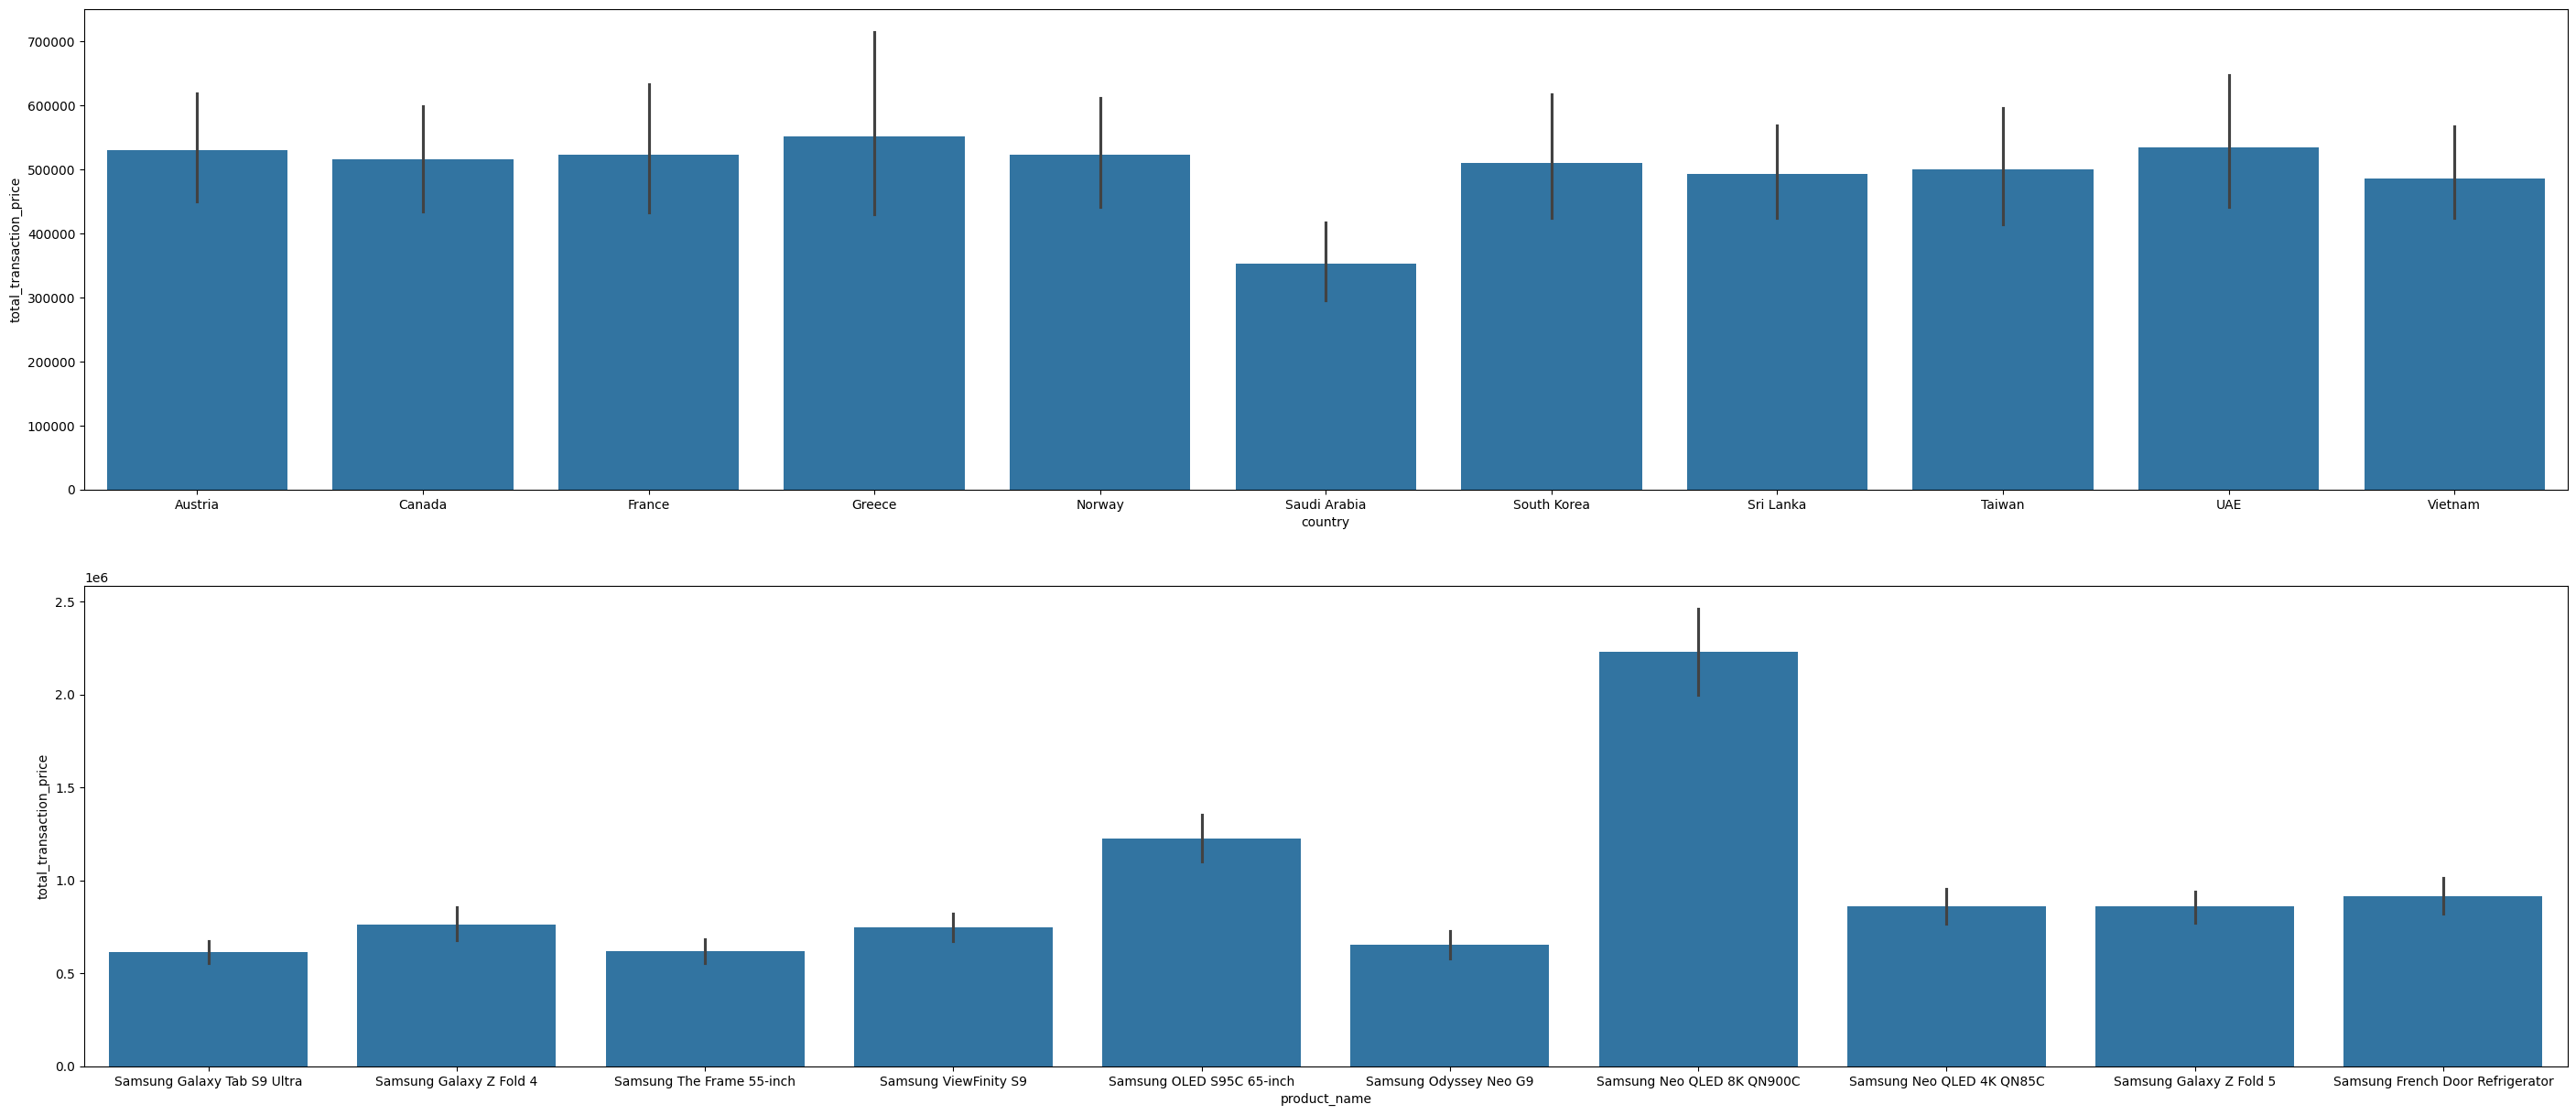

In [ ]:
fig1, axes1 = plt.subplots(2,1,figsize=(35,15))

sn.barplot(data=filtered_country_df, x='country', y='total_transaction_price', estimator=sum, ax=axes1[0])
sn.barplot(data=filtered_product_df, x='product_name', y='total_transaction_price', estimator=sum, ax=axes1[1])

plt.show()

In [ ]:
df['customer_age_group'].unique()

array(['45–54', '55+', '25–34', '18–24', '35–44'], dtype=object)

In [ ]:
age_ser_sum = df.groupby('customer_age_group')['total_transaction_price'].sum()
age_ser_avg = df.groupby('customer_age_group')['total_transaction_price'].mean()

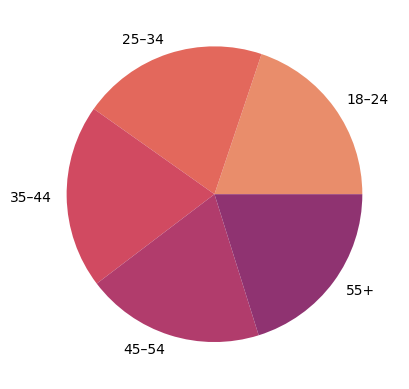

In [ ]:
plt.pie(age_ser_avg, labels=age_ser_avg.index, colors=sn.color_palette('flare'))

plt.show()

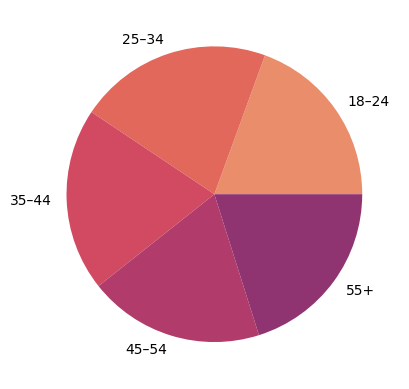

In [ ]:
plt.pie(age_ser_sum, labels=age_ser_sum.index, colors=sn.color_palette('flare'))

plt.show()

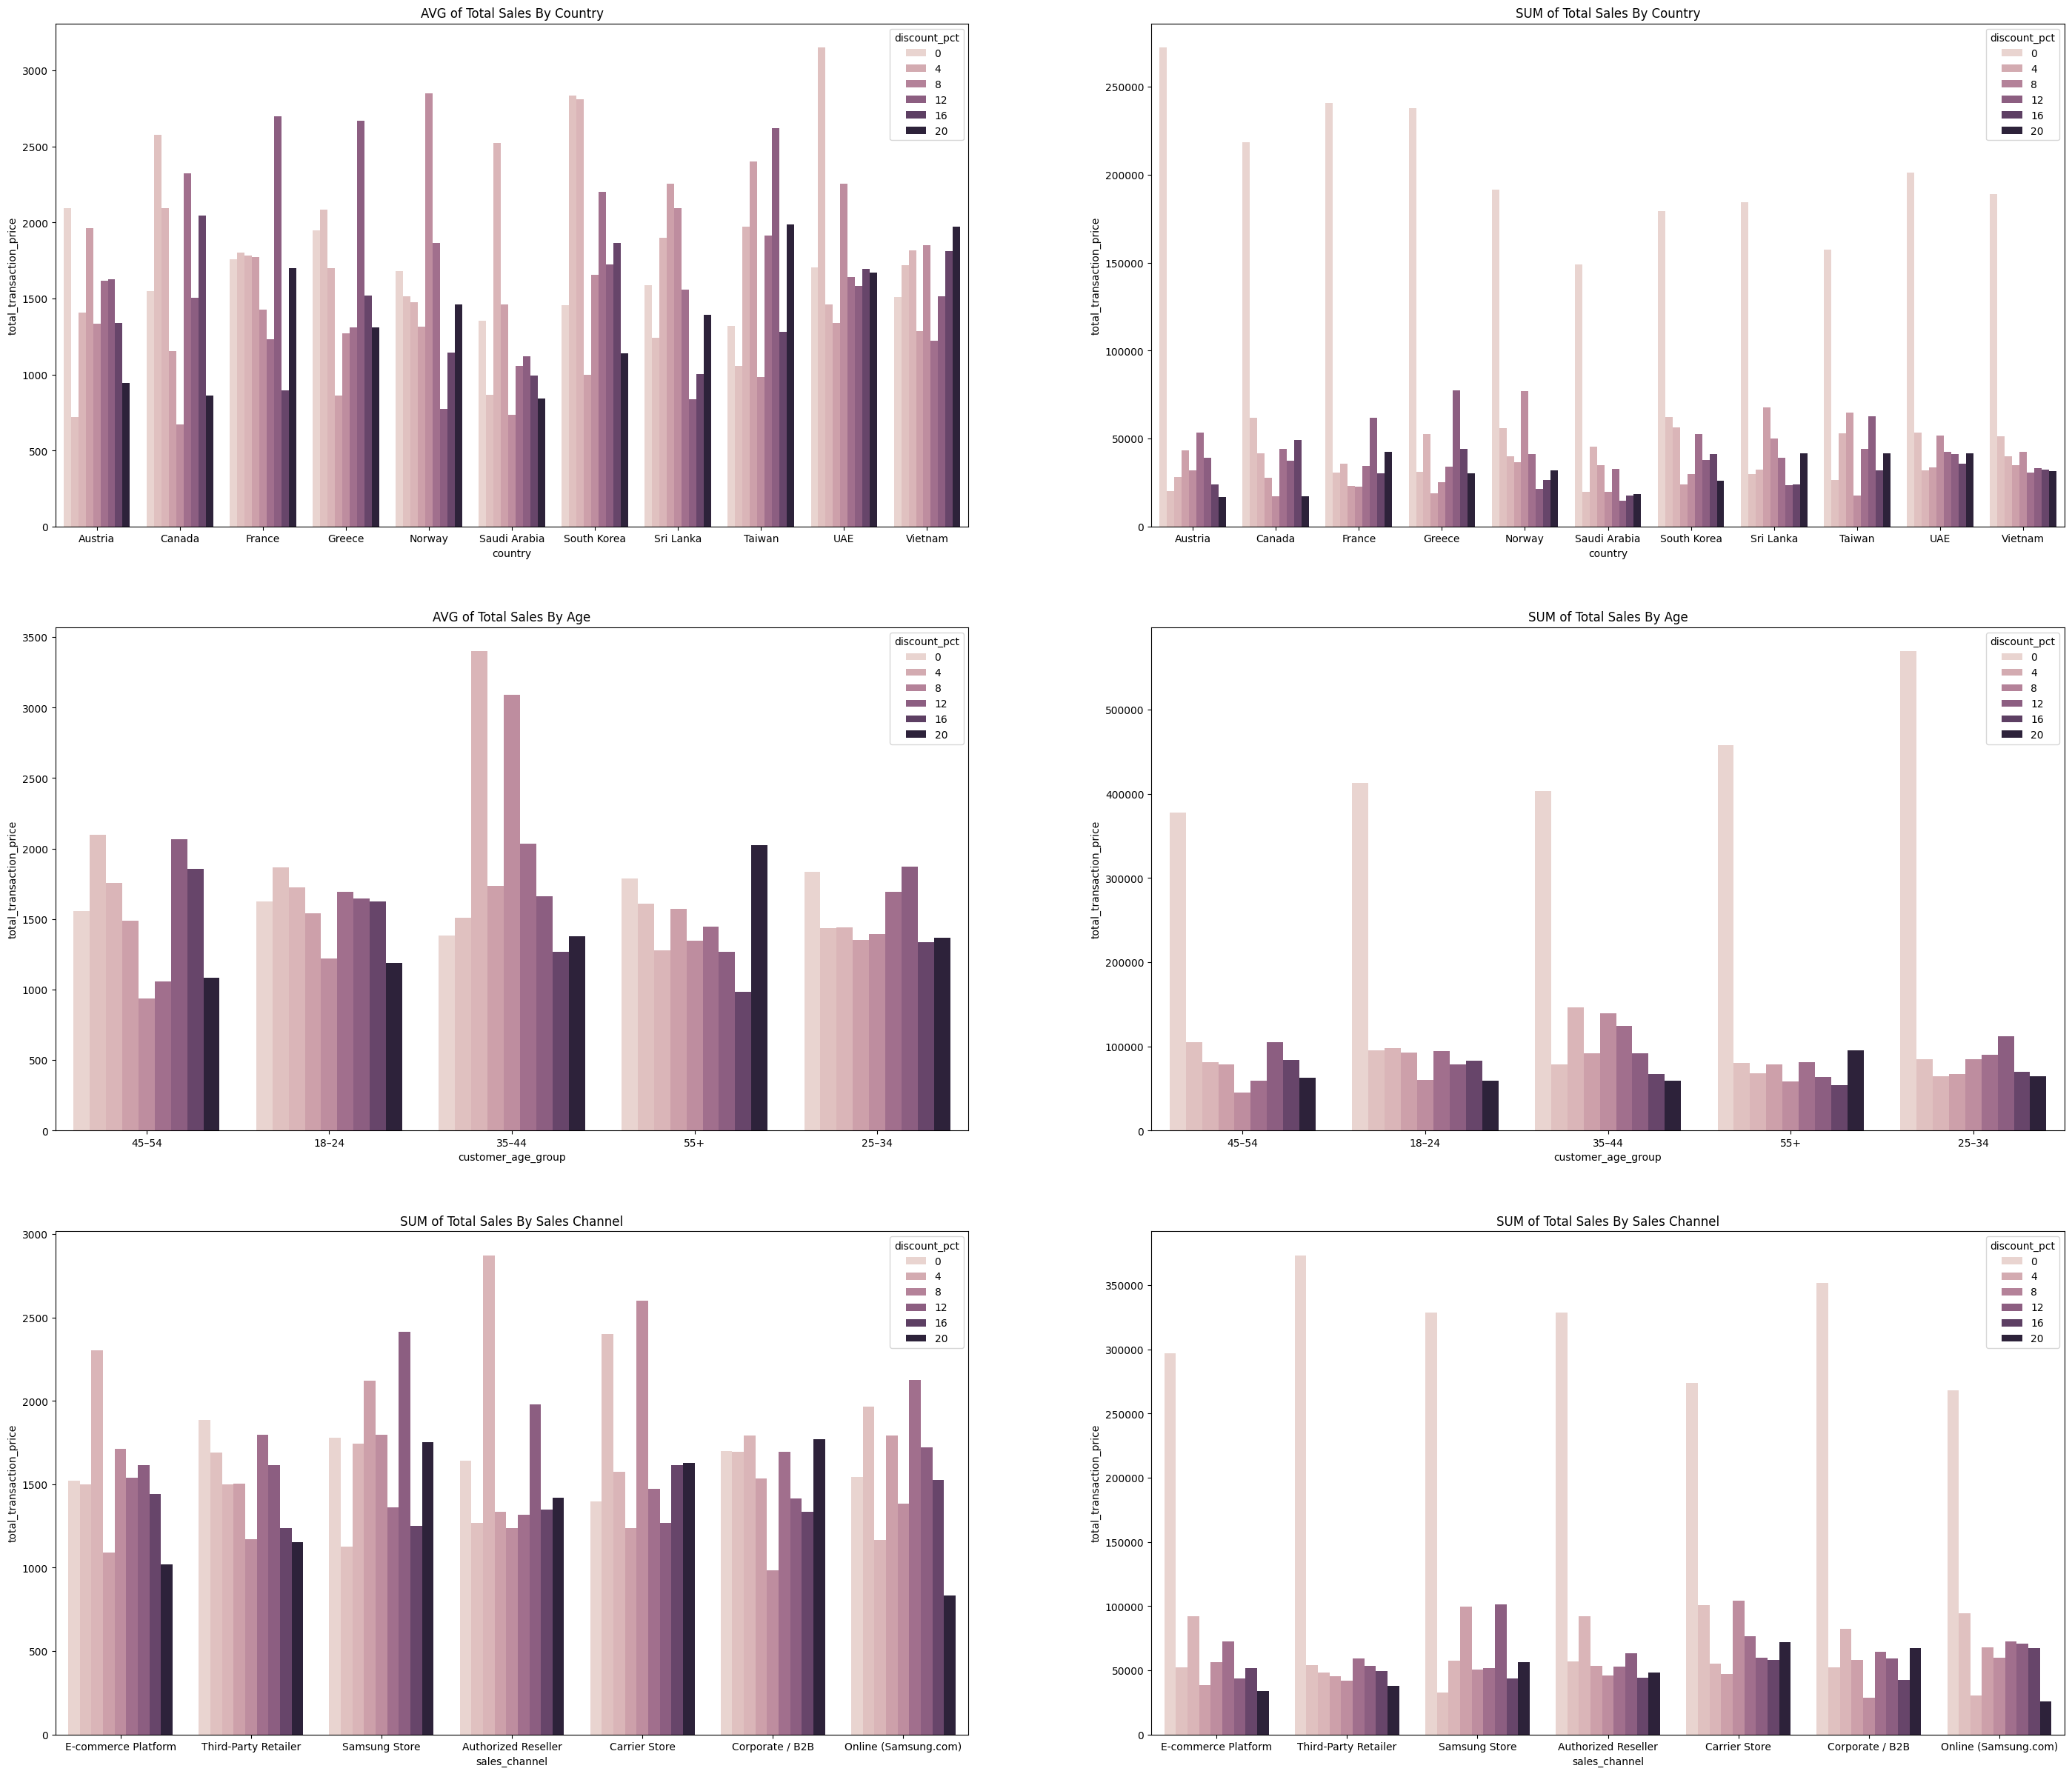

In [ ]:
fig2, axes2 = plt.subplots(3, 2, figsize=(35,30))

sn.barplot(data=filtered_country_df, x='country', y='total_transaction_price', hue='discount_pct', errorbar=None, ax=axes2[0,0])
axes2[0,0].set_title("AVG of Total Sales By Country")
sn.barplot(data=filtered_country_df, x='country', y='total_transaction_price', hue='discount_pct', estimator=sum, errorbar=None, ax=axes2[0,1])
axes2[0,1].set_title("SUM of Total Sales By Country")
sn.barplot(data=filtered_country_df, x='customer_age_group', y='total_transaction_price', hue='discount_pct', errorbar=None, ax=axes2[1,0])
axes2[1,0].set_title('AVG of Total Sales By Age')
sn.barplot(data=filtered_country_df, x='customer_age_group', y='total_transaction_price', hue='discount_pct', estimator=sum, errorbar=None, ax=axes2[1,1])
axes2[1,1].set_title('SUM of Total Sales By Age')
sn.barplot(data=filtered_country_df, x='sales_channel', y='total_transaction_price', hue='discount_pct', errorbar=None, ax=axes2[2,0])
axes2[2,0].set_title('SUM of Total Sales By Sales Channel')
sn.barplot(data=filtered_country_df, x='sales_channel', y='total_transaction_price', hue='discount_pct', estimator=sum, errorbar=None, ax=axes2[2,1])
axes2[2,1].set_title('SUM of Total Sales By Sales Channel')

plt.show()

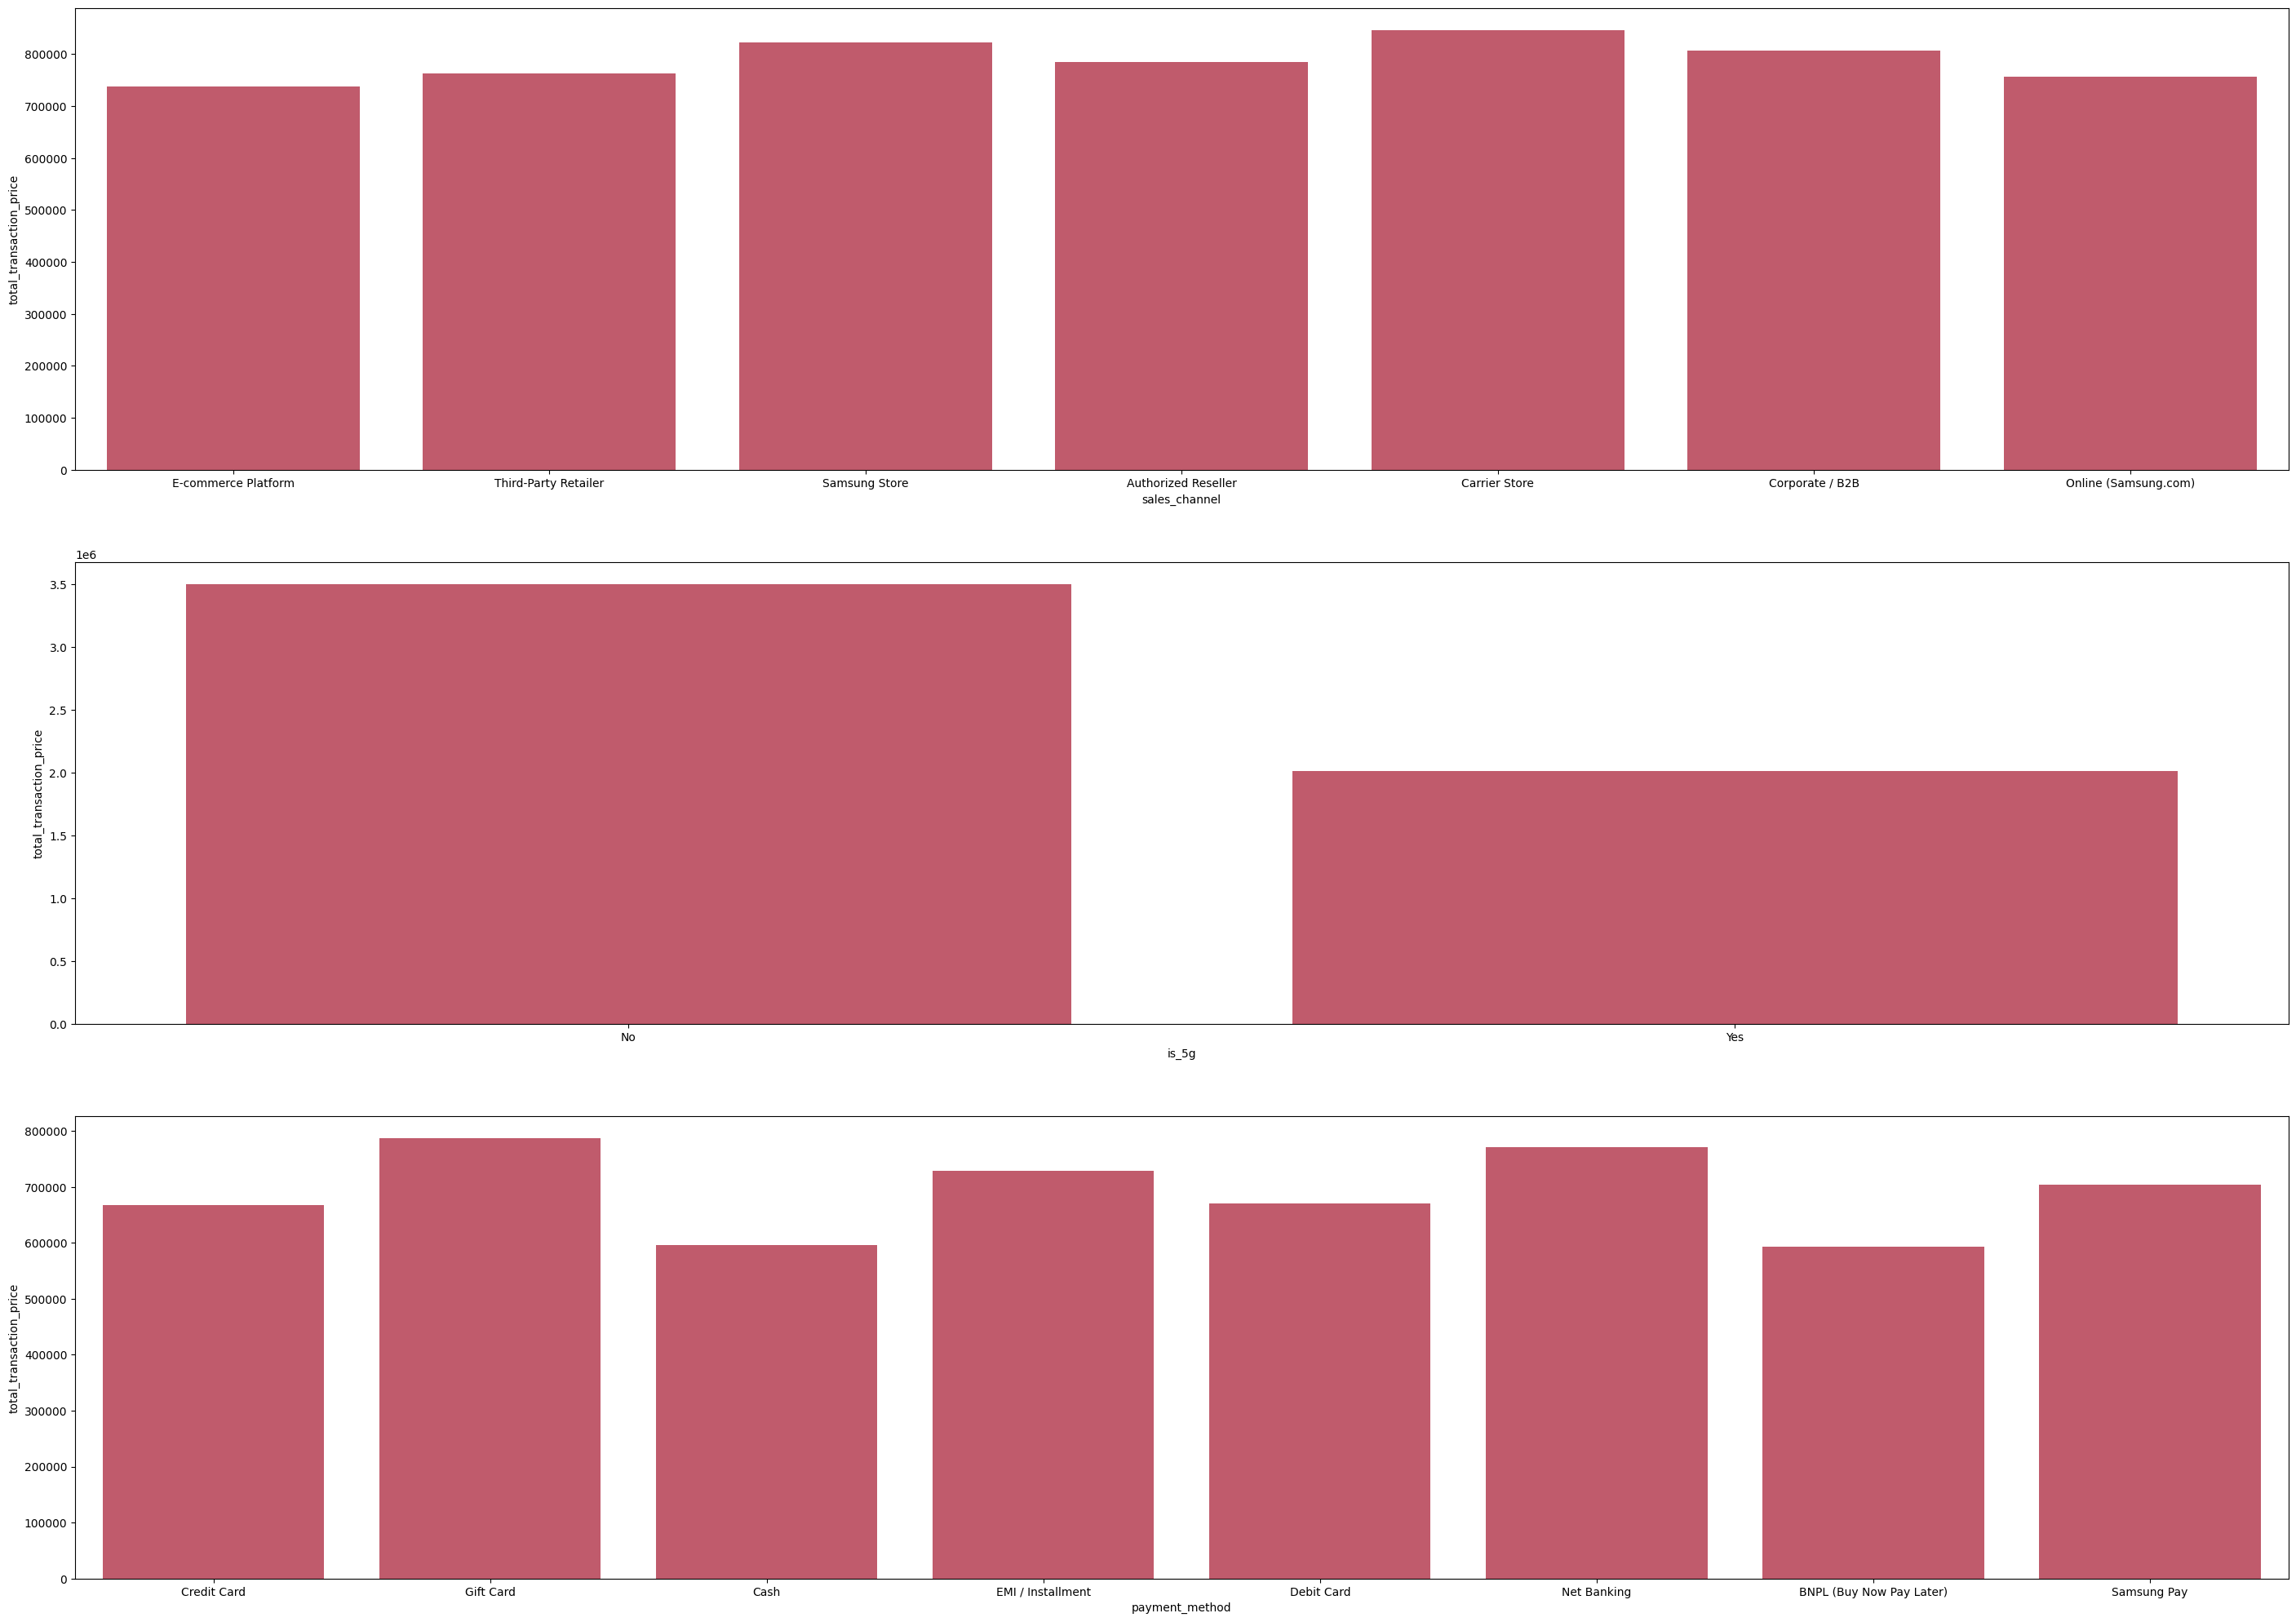

In [ ]:
fig3, axes3 = plt.subplots(3,1,figsize=[35,25])

main_color = sn.color_palette('flare')[2]

sn.barplot(data=filtered_country_df, x='sales_channel', y='total_transaction_price', estimator=sum, errorbar=None, color=main_color, ax=axes3[0])
sn.barplot(data=filtered_country_df, x='is_5g', y='total_transaction_price', estimator=sum, errorbar=None, color=main_color, ax=axes3[1])
sn.barplot(data=filtered_country_df, x='payment_method', y='total_transaction_price', estimator=sum, errorbar=None, color=main_color, ax=axes3[2])

plt.show()

In [ ]:
df['category'].unique()

array(['Galaxy Tab', 'Galaxy S', 'Galaxy A', 'Monitor', 'Galaxy Z',
       'Galaxy Watch', 'Accessories', 'Galaxy M', 'Galaxy Buds',
       'Appliances', 'Smart TV'], dtype=object)

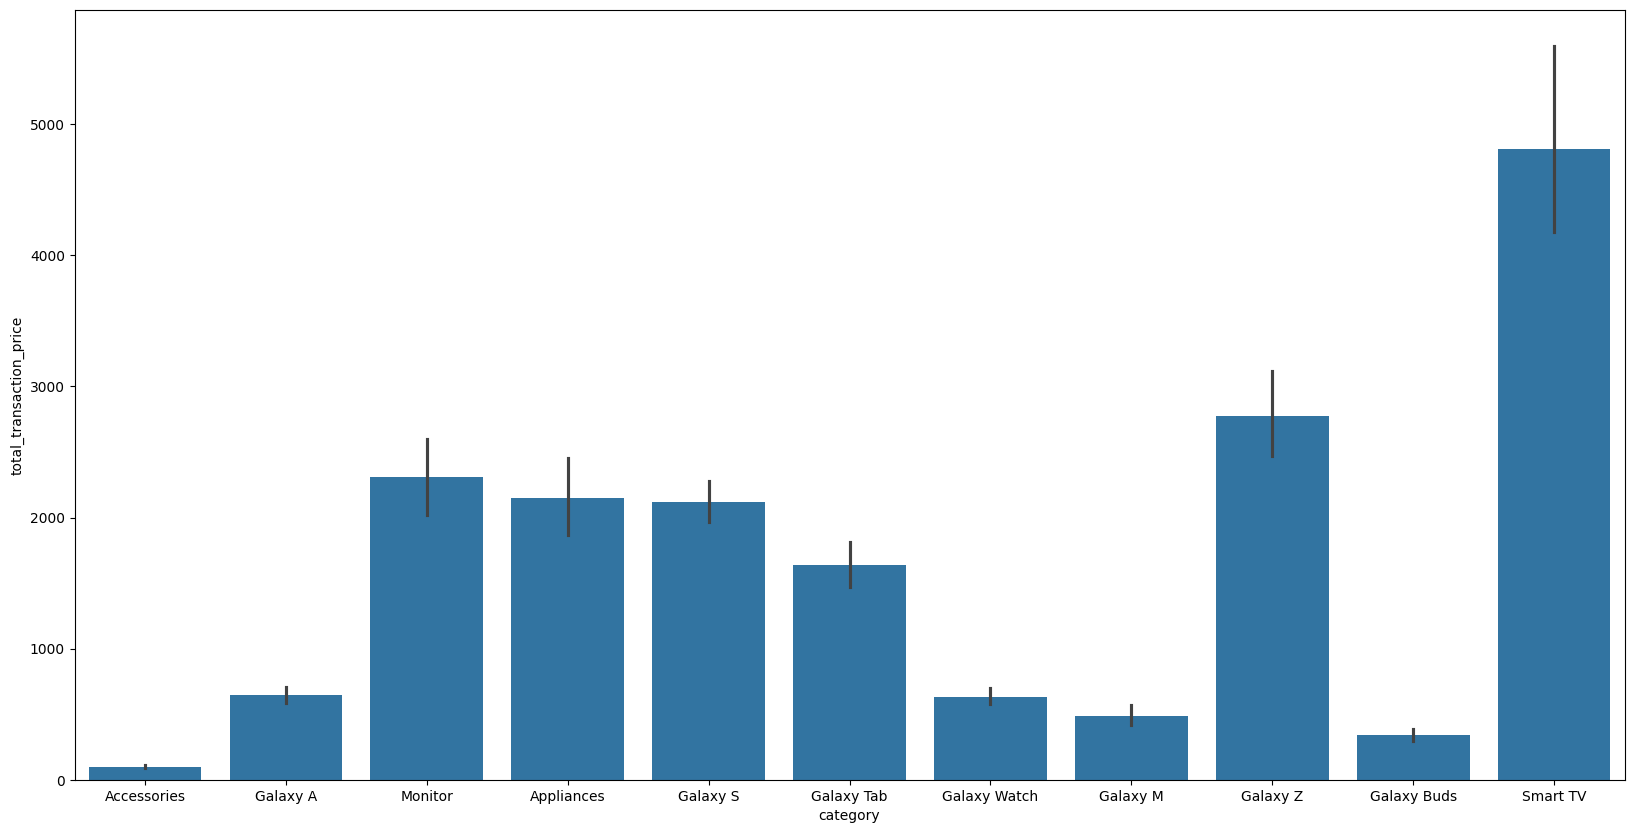

In [ ]:
plt.figure(figsize=(20,10))

sn.barplot(data=filtered_country_df, x='category', y='total_transaction_price')
plt.show()

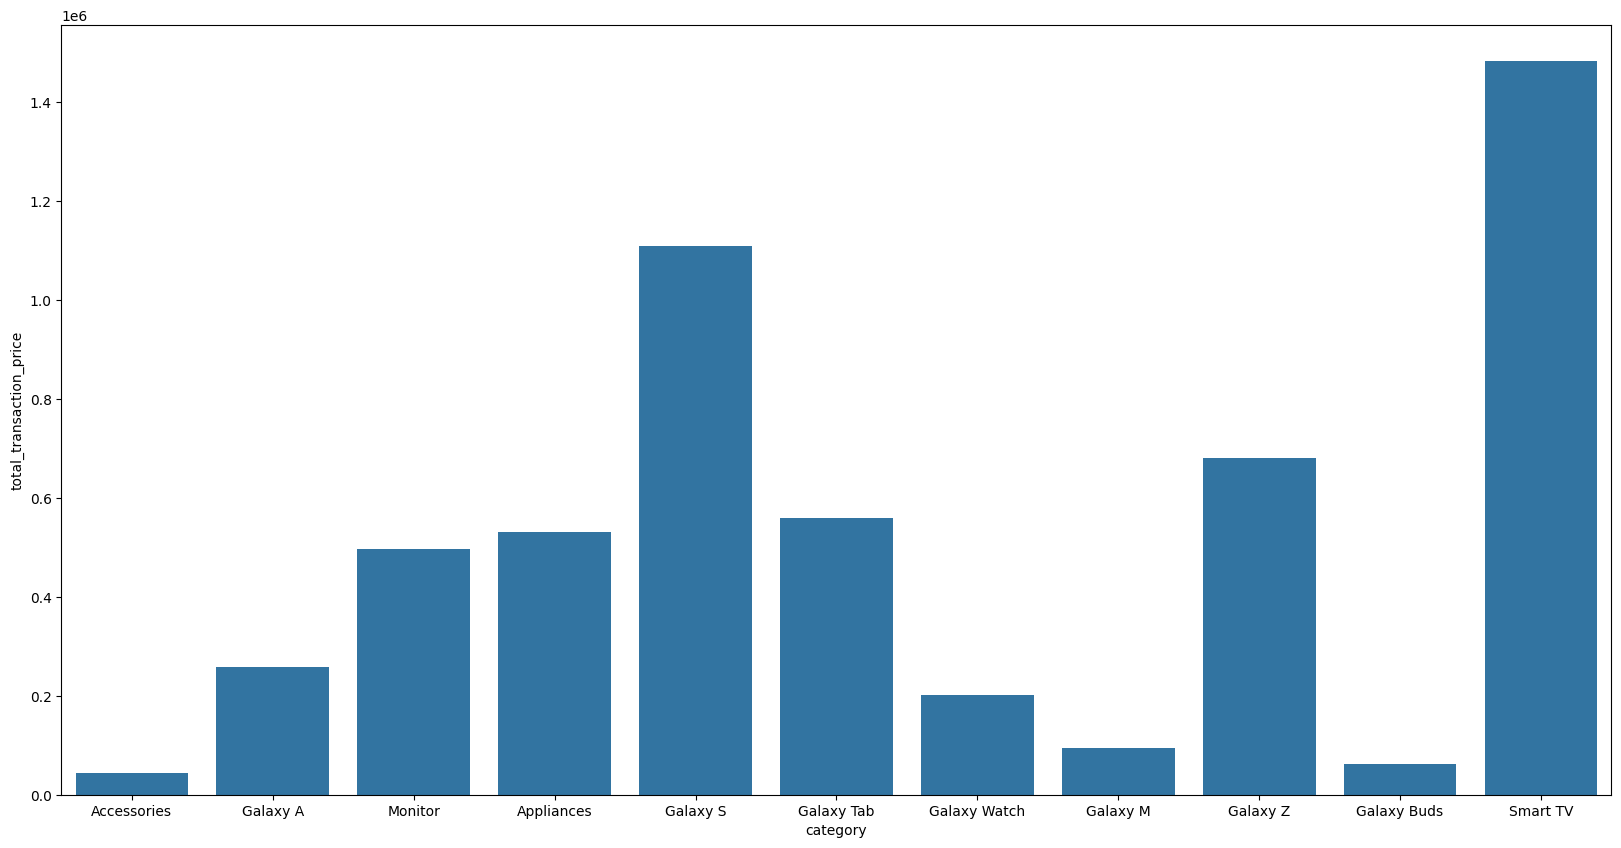

In [ ]:
plt.figure(figsize=(20,10))

sn.barplot(data=filtered_country_df, x='category', y='total_transaction_price', errorbar=None, estimator=sum)
plt.show()

## Drop Unwanted Columns:

- Drop them based if they're useful to analyze data or predict the future sales.
- We interested only on **11** countries listed in country_ser.
- For dashboard will focus on product_name & category, but for prediction will focus only on category.

In [ ]:
# check from the shape again:
filtered_country_df.shape

(3420, 29)

In [ ]:
# drop unnecessary columns for dashboard:

dashboard_df = filtered_country_df.drop(columns=['sale_id', 'year', 'quarter', 'month', 'region', 'city', 'storage', 'currency', 'fx_rate_to_usd', 'revenue_local_currency', 'customer_segment'])

In [ ]:
dashboard_df.to_csv('/content/drive/MyDrive/dashboard_samsung.csv')

In [ ]:
# drop unnecessary columns for prediction:

predict_df = filtered_country_df.drop(columns=['sale_id', 'quarter', 'region', 'city', 'storage', 'currency', 'fx_rate_to_usd', 'revenue_local_currency', 'customer_segment', 'product_name', 'color', 'unit_price_usd', 'revenue_usd', 'customer_age_group', 'previous_device_os', 'customer_rating', 'return_status'])

In [ ]:
# change the type of sale_date column:

predict_df['sale_date'] = pd.to_datetime(predict_df['sale_date'])

In [ ]:
# change the month name to number & extract day

predict_df['month'] = predict_df['sale_date'].dt.month
predict_df['day'] = predict_df['sale_date'].dt.day

In [ ]:
# drop is_5g since it won't give model any beneficial values for prediction (only contain 2 values):

predict_df = predict_df.drop(columns=['is_5g'])

In [ ]:
def map_val(values_list, dic):
  c = len(values_list)
  for i in range(c):
    dic[values_list[i]] = i

  return dic

In [ ]:
predict_df.describe(include='object')

,country,category,sales_channel,payment_method
count,3420,3420,3420,3420
unique,11,11,7,8
top,Norway,Galaxy S,Carrier Store,EMI / Installment
freq,328,523,530,466


In [ ]:
# change each string value to integer value:

cat = {}
country = {}
channel = {}
payment = {}

cat = map_val(predict_df['category'].unique(), cat)
country = map_val(predict_df['country'].unique(), country)
channel = map_val(predict_df['sales_channel'].unique(), channel)
payment = map_val(predict_df['payment_method'].unique(), payment)

In [ ]:
# map cat values to num values:

predict_df['country'] = predict_df['country'].map(country)
predict_df['category'] = predict_df['category'].map(cat)
predict_df['sales_channel'] = predict_df['sales_channel'].map(channel)
predict_df['payment_method'] = predict_df['payment_method'].map(payment)

In [ ]:
predict_df.head(5)

,sale_date,year,month,country,category,discount_pct,units_sold,discounted_price_usd,sales_channel,payment_method,total_transaction_price,day
604,2021-01-29,2021,1,0,0,10,2,7.60,0,0,15.20,29
605,2021-06-18,2021,6,0,1,15,1,121.44,1,1,121.44,18
606,2021-06-22,2021,6,0,2,0,1,1557.93,2,1,1557.93,22
607,2021-06-24,2021,6,0,3,0,1,780.42,3,0,780.42,24
608,2021-07-29,2021,7,0,2,12,10,206.87,0,2,2068.70,29


In [ ]:
# drop sale_date since isn't important after etracting data:

predict_df = predict_df.drop(columns=['sale_date'])

In [ ]:
# sort values based on date:

predict_df = predict_df.sort_values(by=['year','month','day'])

In [ ]:
predict_df.head(5)

,year,month,country,category,discount_pct,units_sold,discounted_price_usd,sales_channel,payment_method,total_transaction_price,day
891,2021,1,0,1,2,1,113.29,5,4,113.29,1
11019,2021,1,5,7,0,1,353.85,1,4,353.85,1
12362,2021,1,7,10,0,2,2572.66,3,2,5145.32,1
632,2021,1,0,7,7,3,346.95,1,6,1040.85,2
8535,2021,1,4,3,2,1,734.81,0,0,734.81,2


In [ ]:
# correlation process:

corr_df = predict_df.corr()
corr_df.head(5)

,year,month,country,category,discount_pct,units_sold,discounted_price_usd,sales_channel,payment_method,total_transaction_price,day
year,1.000000,-0.003172,0.000296,-0.020732,0.019812,-0.040827,0.000513,0.009625,-0.007221,-0.014513,-0.001598
month,-0.003172,1.000000,-0.007274,0.009441,-0.003437,-0.011099,0.007278,-0.005108,0.007852,0.026035,0.017574
country,0.000296,-0.007274,1.000000,0.006064,0.005627,0.010643,0.003153,-0.018746,0.049675,-0.002582,-0.002101
category,-0.020732,0.009441,0.006064,1.000000,0.003121,-0.003675,0.422626,0.006022,-0.006095,0.275475,0.011159
discount_pct,0.019812,-0.003437,0.005627,0.003121,1.000000,0.013047,-0.045456,0.017161,-0.004637,-0.027434,0.016896


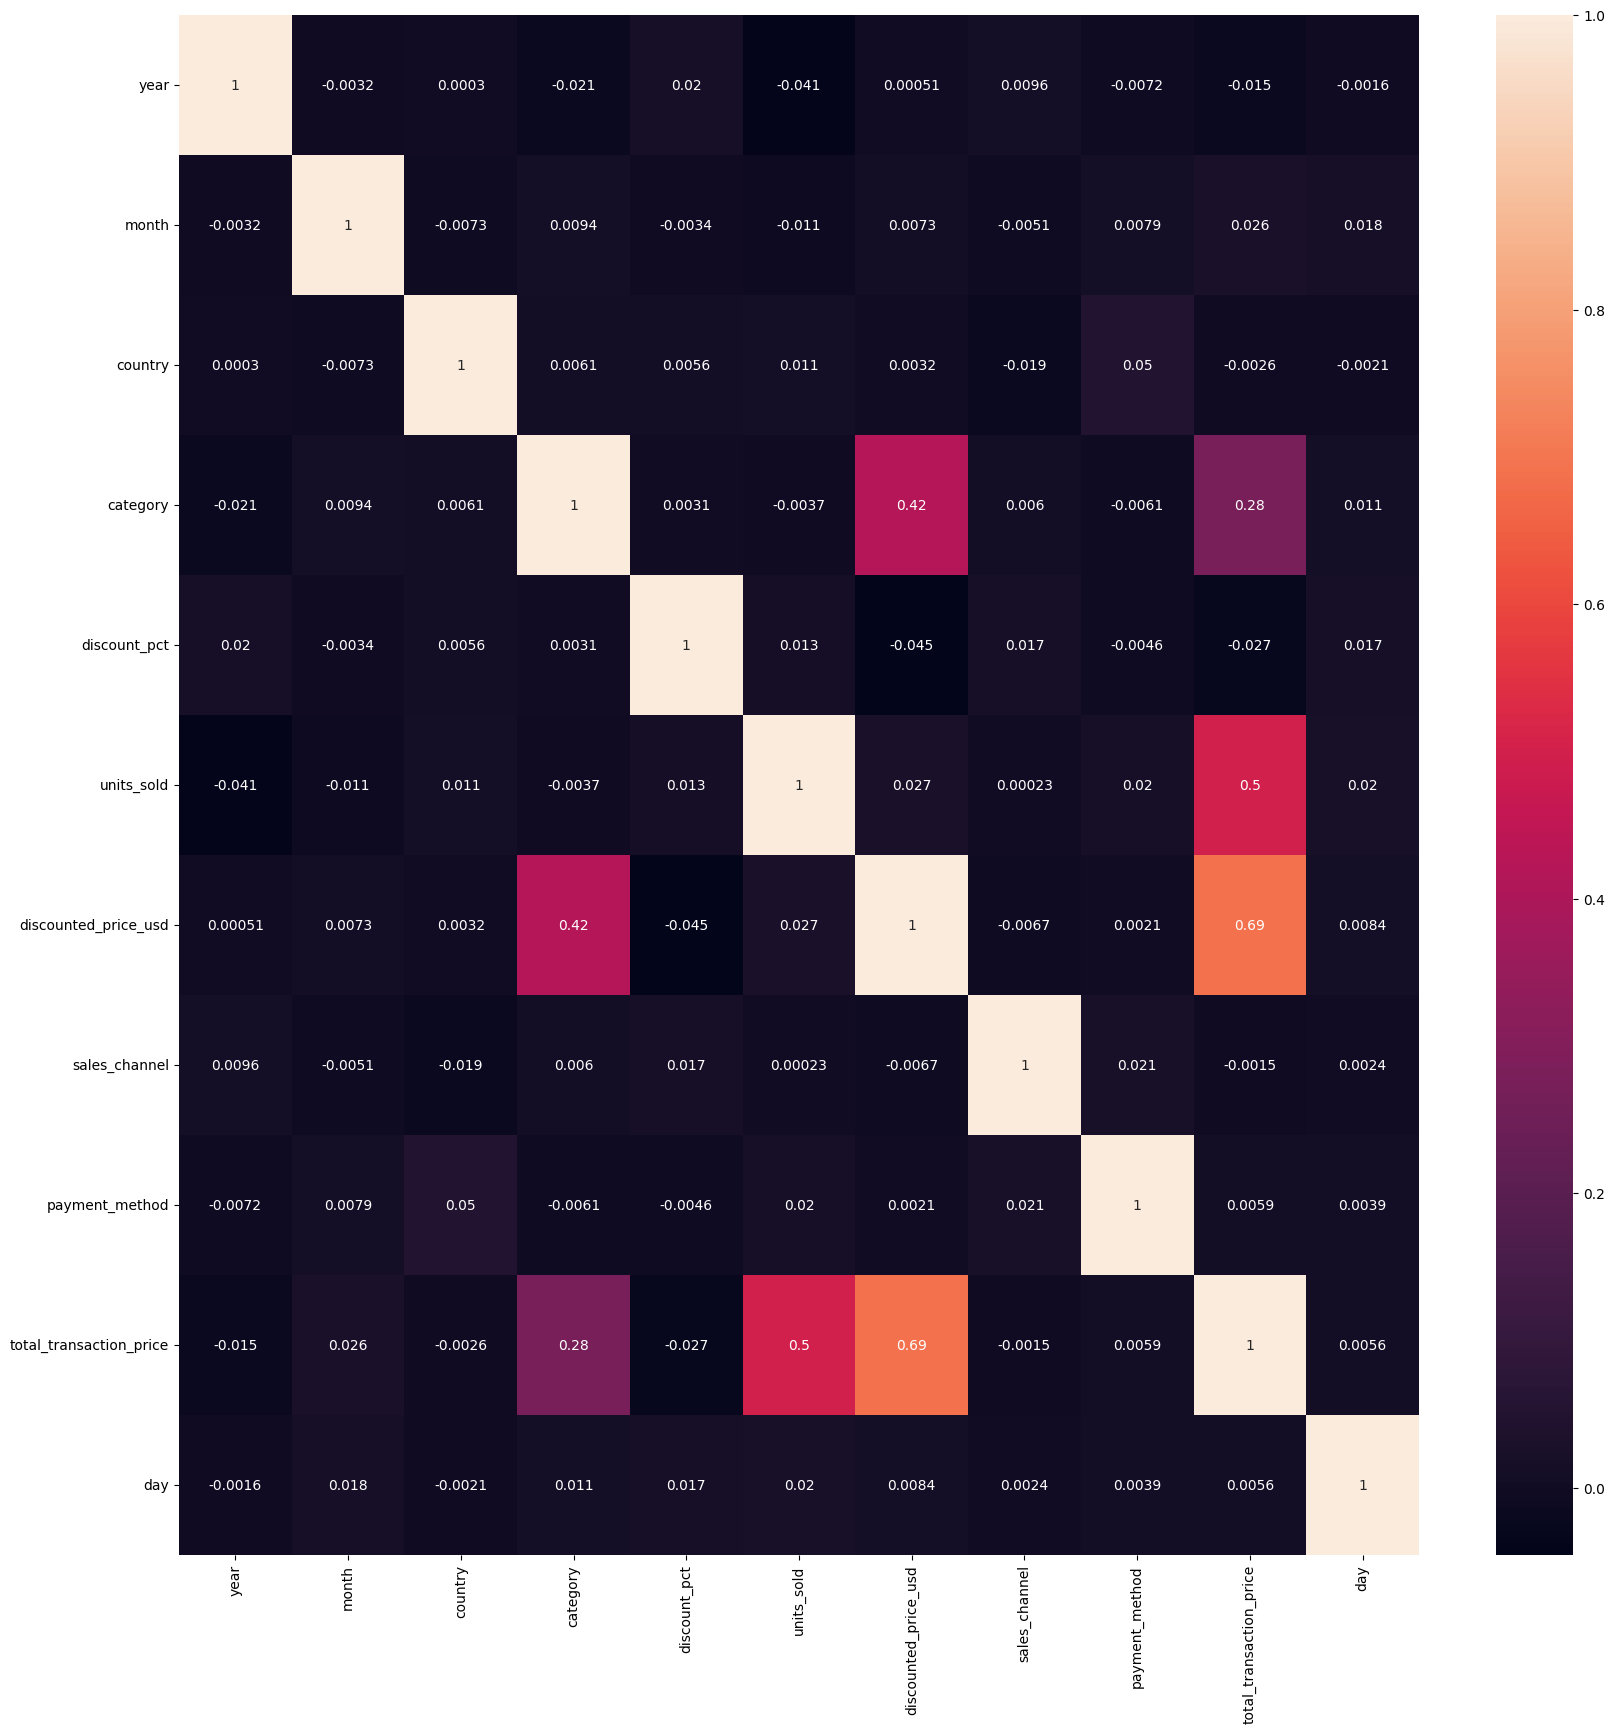

In [ ]:
plt.figure(figsize=(20,20))
sn.heatmap(data=corr_df, annot=True)

plt.show()

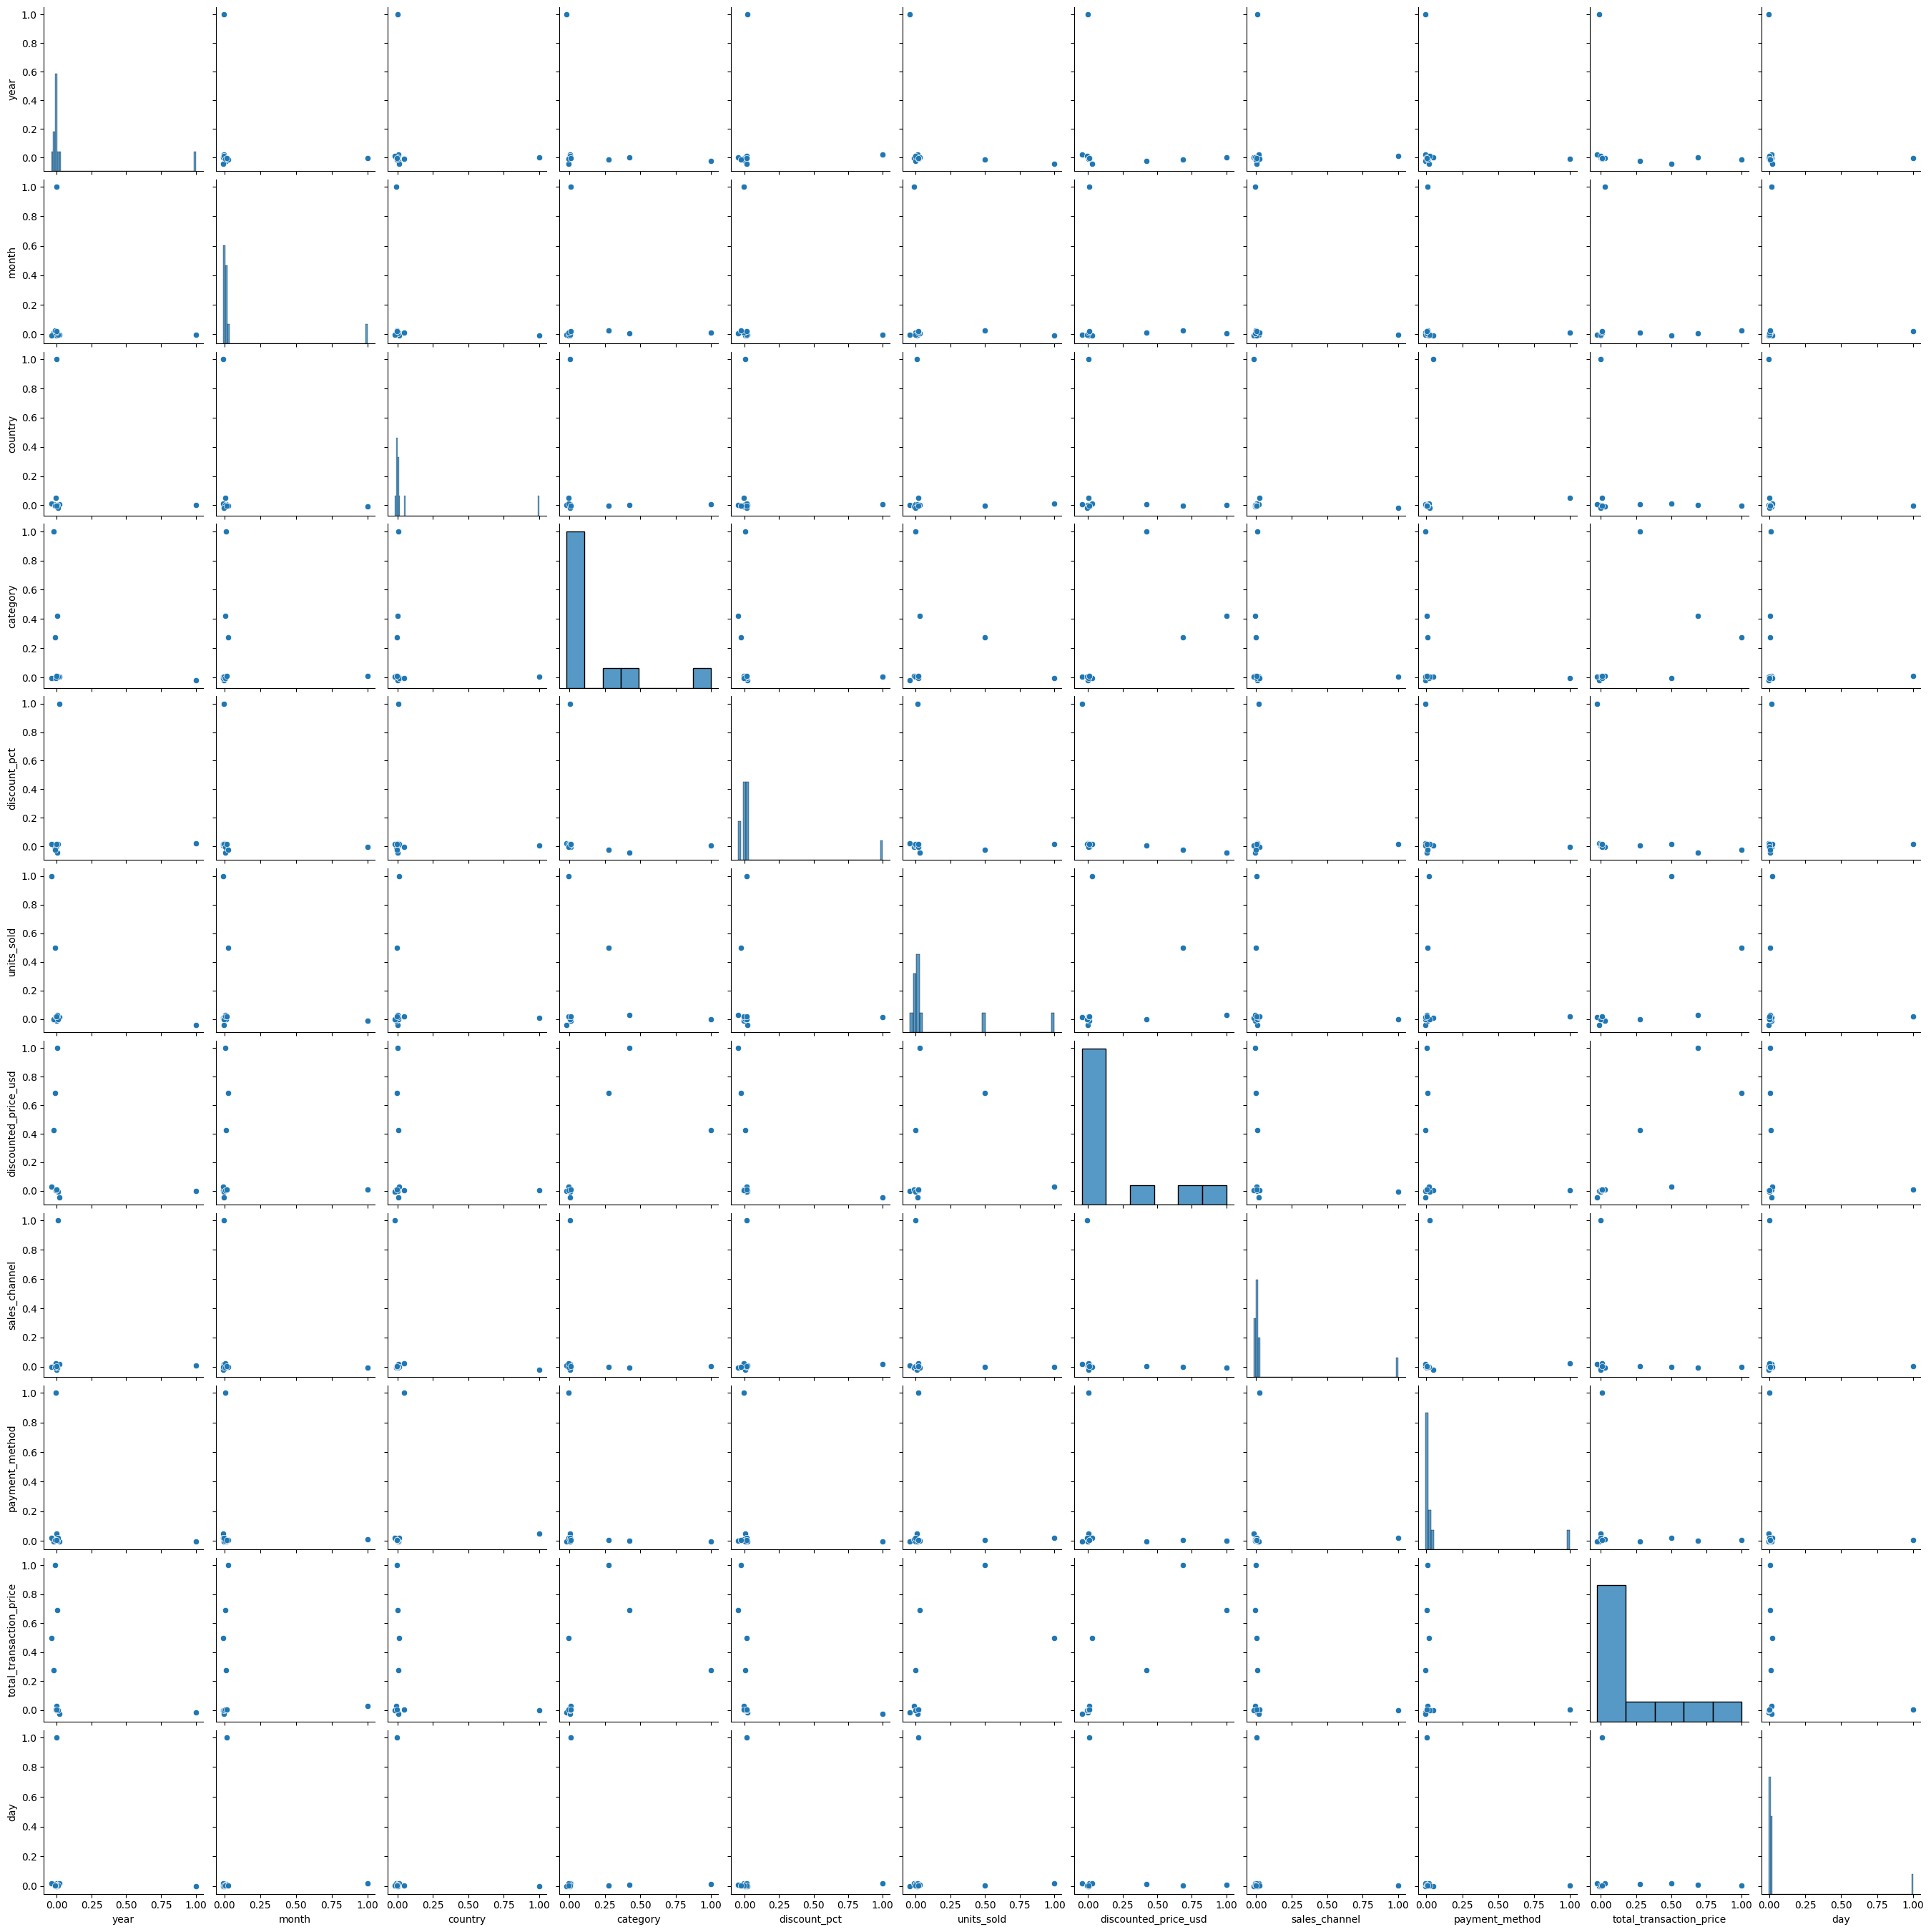

In [ ]:
sn.pairplot(data=corr_df, corner=False)

plt.show()

## insights About Needed clumns for Prediction:

From graphs above we see that each pair of columns has no linear or relation, so will use other techniques for decrease the number of columns for prediction.
<br>Also we found in last cellsthe is_5g column give no usefull data for prediction (contain only 2 values),also id columns and product name which confuse the model without provide beneficial to prediction process so they'll be dropped.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
selector = VarianceThreshold()
x_selector = selector.fit_transform(predict_df)

feature_var = selector.variances_

print(predict_df.columns)
print(feature_var)

Index(['year', 'month', 'country', 'category', 'discount_pct', 'units_sold',
       'discounted_price_usd', 'sales_channel', 'payment_method',
       'total_transaction_price', 'day'],
      dtype='object')
[1.26049340e+00 1.10000000e+01 1.00000000e+01 9.92679765e+00
 2.00000000e+01 3.67891274e+00 5.35806000e+03 3.94929132e+00
 5.18654244e+00 4.76584500e+04 3.00000000e+01]


In [ ]:
var_df = pd.DataFrame(data={'name' : predict_df.columns, 'variance' : feature_var})

In [ ]:
var_df.sort_values(by='variance')

,name,variance
0,year,1.260493
5,units_sold,3.678913
7,sales_channel,3.949291
8,payment_method,5.186542
3,category,9.926798
2,country,10.000000
1,month,11.000000
4,discount_pct,20.000000
10,day,30.000000
6,discounted_price_usd,5358.060000


# Build Prediction Model:

In [ ]:
%pip install xgboost

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
condition = (predict_df['year'] == 2024)
test_set = predict_df.loc[condition]
train_set = predict_df.loc[~condition]

In [ ]:
x_train = np.array(train_set.drop(columns=['total_transaction_price']))
y_train = np.array(train_set['total_transaction_price'])

x_test = np.array(test_set.drop(columns=['total_transaction_price']))
y_test = np.array(test_set['total_transaction_price'])

In [ ]:
# scale feature data:

scalar = StandardScaler()
x_scale_train = scalar.fit_transform(x_train)
x_scale_test = scalar.transform(x_test)

In [ ]:
# prepare models:

xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=6 ,random_state=42)
RF_model = RandomForestRegressor(n_estimators=1000, max_depth=6, random_state=42)
SVR_model = SVR()
param_grid = {'C' : [10, 1, 0.1, 0.01, 0.001], 'gamma' : ['scale', 'auto', 1, 0.1, 0.01]}
grid_model = GridSearchCV(estimator=SVR_model, cv=5, param_grid=param_grid)

In [ ]:
xgb_model.fit(x_scale_train, y_train, eval_set=[(x_scale_test, y_test)])

[0]	validation_0-rmse:2266.94004
[1]	validation_0-rmse:2246.43052
[2]	validation_0-rmse:2226.69240
[3]	validation_0-rmse:2206.60662
[4]	validation_0-rmse:2186.85760
[5]	validation_0-rmse:2167.14467
[6]	validation_0-rmse:2147.81566
[7]	validation_0-rmse:2128.49412
[8]	validation_0-rmse:2109.52354
[9]	validation_0-rmse:2090.60797
[10]	validation_0-rmse:2072.00193
[11]	validation_0-rmse:2053.41983
[12]	validation_0-rmse:2035.19299
[13]	validation_0-rmse:2017.02893
[14]	validation_0-rmse:1999.25162
[15]	validation_0-rmse:1981.65374
[16]	validation_0-rmse:1963.97869
[17]	validation_0-rmse:1946.68484
[18]	validation_0-rmse:1929.39196
[19]	validation_0-rmse:1912.38063
[20]	validation_0-rmse:1895.57829
[21]	validation_0-rmse:1878.71831
[22]	validation_0-rmse:1862.27653
[23]	validation_0-rmse:1846.58576
[24]	validation_0-rmse:1830.22612
[25]	validation_0-rmse:1814.30581
[26]	validation_0-rmse:1798.28789
[27]	validation_0-rmse:1782.30738
[28]	validation_0-rmse:1766.50810
[29]	validation_0-rmse:1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
RF_model.fit(x_scale_train, y_train)

RandomForestRegressor(max_depth=6, n_estimators=1000, random_state=42)

In [ ]:
grid_model.fit(x_scale_train, y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [10, 1, 0.1, 0.01, 0.001],
                         'gamma': ['scale', 'auto', 1, 0.1, 0.01]})

In [ ]:
grid_model.best_params_

{'C': 10, 'gamma': 'scale'}

In [ ]:
# evaluate the models:

pred_xgb = xgb_model.predict(x_scale_test)
pred_rf = RF_model.predict(x_scale_test)
pred_svr = grid_model.predict(x_scale_test)


In [ ]:
# evaluate the models:

print(f'The R2 score of XGBOOST REGRESSION model: {r2_score(y_pred=pred_xgb, y_true=y_test)}')
print(f'The R2 score on RANDOM FOREST REGRESSION model: {r2_score(y_pred=pred_rf, y_true=y_test)}')
print(f'The R2 score of SVR model: {r2_score(y_pred=pred_svr, y_true=y_test)}')

print(f'\nThe MAE of XGBOOST REGRESSION model: {mean_absolute_error(y_pred=pred_xgb, y_true=y_test)}')
print(f'The MAE on RANDOM FOREST REGRESSION model: {mean_absolute_error(y_pred=pred_rf, y_true=y_test)}')
print(f'The MAE of SVR model: {mean_absolute_error(y_pred=pred_svr, y_true=y_test)}')

print(f'\nThe MSE of XGBOOST REGRESSION model: {mean_squared_error(y_pred=pred_xgb, y_true=y_test)}')
print(f'The MSE on RANDOM FOREST REGRESSION model: {mean_squared_error(y_pred=pred_rf, y_true=y_test)}')
print(f'The MSE of SVR model: {mean_squared_error(y_pred=pred_svr, y_true=y_test)}')

The R2 score of XGBOOST REGRESSION model: 0.9960796874876399
The R2 score on RANDOM FOREST REGRESSION model: 0.9893828828174044
The R2 score of SVR model: 0.06783502336412583

The MAE of XGBOOST REGRESSION model: 40.52608572215309
The MAE on RANDOM FOREST REGRESSION model: 103.8387903463934
The MAE of SVR model: 1035.2017480668833

The MSE of XGBOOST REGRESSION model: 20452.777466125488
The MSE on RANDOM FOREST REGRESSION model: 55390.873656823045
The MSE of SVR model: 4863225.25786894


In [ ]:
print(cat)
print(country)
print(channel)
print(payment)

{'Accessories': 0, 'Galaxy A': 1, 'Monitor': 2, 'Appliances': 3, 'Galaxy S': 4, 'Galaxy Tab': 5, 'Galaxy Watch': 6, 'Galaxy M': 7, 'Galaxy Z': 8, 'Galaxy Buds': 9, 'Smart TV': 10}
{'Austria': 0, 'Canada': 1, 'France': 2, 'Greece': 3, 'Norway': 4, 'Saudi Arabia': 5, 'South Korea': 6, 'Sri Lanka': 7, 'Taiwan': 8, 'UAE': 9, 'Vietnam': 10}
{'E-commerce Platform': 0, 'Third-Party Retailer': 1, 'Samsung Store': 2, 'Authorized Reseller': 3, 'Carrier Store': 4, 'Corporate / B2B': 5, 'Online (Samsung.com)': 6}
{'Credit Card': 0, 'Gift Card': 1, 'Cash': 2, 'EMI / Installment': 3, 'Debit Card': 4, 'Net Banking': 5, 'BNPL (Buy Now Pay Later)': 6, 'Samsung Pay': 7}


In [ ]:
def pred_1_month(model, arr, scale):
  result = 0
  pred = 0

  for i in range(1,31):
    arr[0, 9] = i
    arr_scaled = scale.transform(arr)
    pred = model.predict(arr_scaled)
    result = result + pred[0]

  return result

In [ ]:
# check the arrange of columns:

predict_df.columns

Index(['year', 'month', 'country', 'category', 'discount_pct', 'units_sold',
       'discounted_price_usd', 'sales_channel', 'payment_method',
       'total_transaction_price', 'day'],
      dtype='object')

In [ ]:
# predict prices of: 2026, march, Galaxy S, Norway, Third-Party Retailer, Credit Card

x_2026 = np.array([[2026, 3, 4, 4, 0, 1, 899.99, 1, 0, 0]])
x_2026_scaled = scalar.transform(x_2026)

pred_2026_xgb = pred_1_month(xgb_model, x_2026, scalar)
pred_2026_rf = pred_1_month(RF_model, x_2026, scalar)

In [ ]:
pred_2026_xgb

np.float32(26695.836)

In [ ]:
pred_2026_rf

np.float64(25948.526357270308)

In [ ]:
import joblib

joblib.dump(xgb_model, '/content/drive/MyDrive/xgb_model.joblib')
joblib.dump(RF_model, '/content/drive/MyDrive/rf_model.joblib')

['/content/drive/MyDrive/rf_model.joblib']